# BBI Slope Factor Analysis

## Research Objective
This notebook evaluates the predictive value, stability, and practical usefulness of the **BBI downward-slope factor** inside the Dynamic Mean Reversion & Multi-Factor Flow Alpha stock pool. The focus is not whether the factor can independently generate strong alpha, but whether it provides a reliable **defensive confirmation signal** when the strategy considers reducing or exiting risk exposure.


## Factor Definition
The factor is built from the same BBI proxy used in the strategy code:

- **BBI = average(MA10, MA20, MA30, MA60)**
- A **bearish BBI signal** is triggered when the current BBI value is lower than the previous BBI value.

## Research Hypothesis
The working hypothesis is that a downward BBI slope may indicate weakening short-term trend support. If the hypothesis holds, stocks with this bearish signal should deliver weaker next-period returns than stocks without the signal.

## Data and Test Design
The factor is tested on the strategy's fixed 33-stock pool over **2016-01-01 to 2026-04-29**, using monthly cross-sectional snapshots aligned with the reference factor notebooks. The analysis includes rank IC, signal-versus-non-signal return comparison, rolling spread inspection, signal frequency tracking, and annual regime-style attribution.


Initiating BBI Slope Factor Diagnostic...
Processing Snapshot: 2026-03-31
Data collection complete.


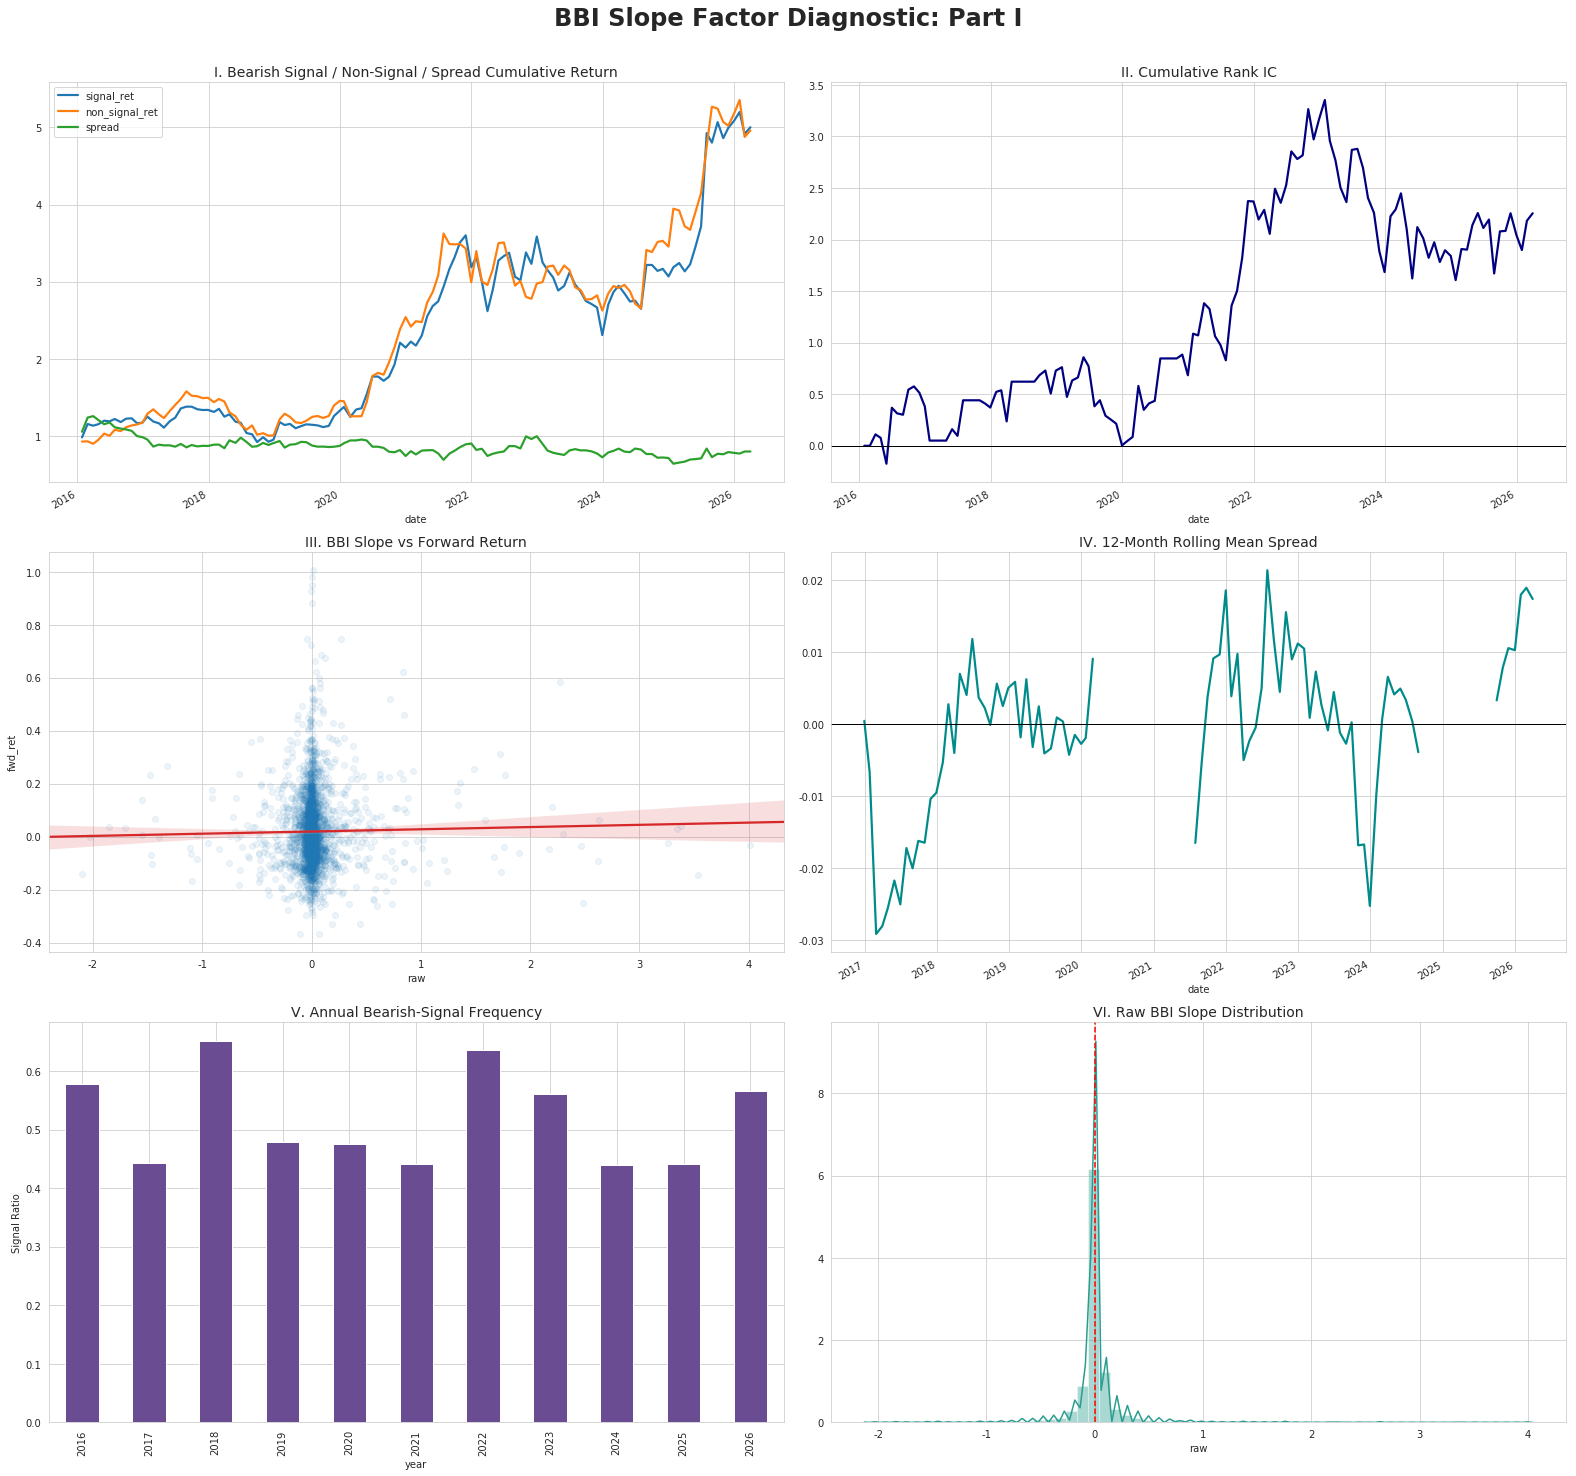

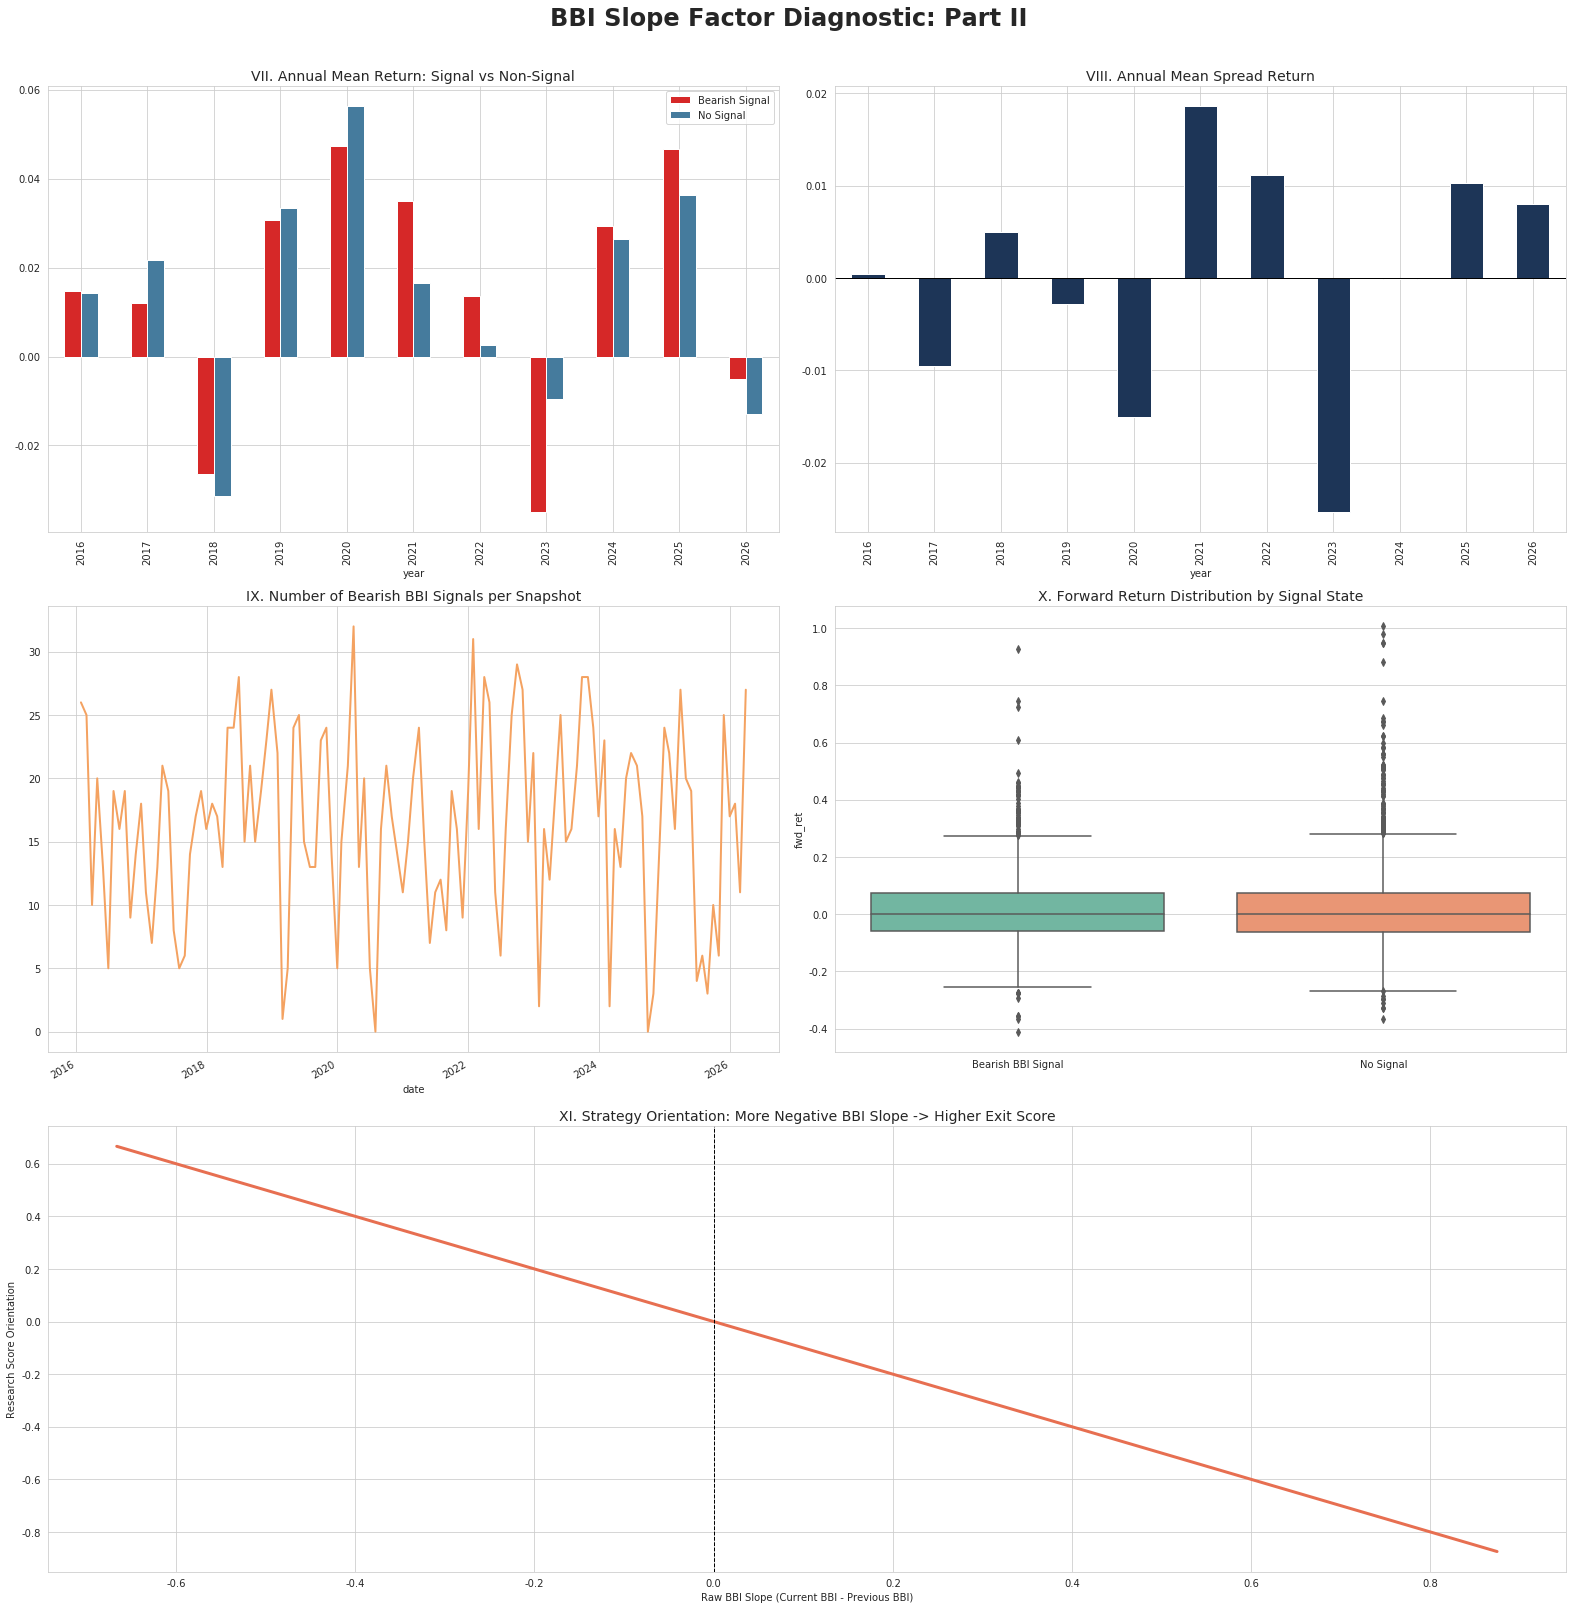


FINAL SUMMARY: BBI DOWNWARD SLOPE FACTOR
------------------------------------------------------------------------------------------
Average Rank IC: 0.0209
ICIR: 0.0843
Bearish Signal Mean Return: 1.59%
Non-Signal Mean Return: 1.56%
Signal Spread Mean Return: -0.03%


In [3]:
'''
This diagnostic evaluates the "BBI Downward Slope" factor used by the
Dynamic Mean Reversion & Multi-Factor Flow Alpha strategy.

Core Logic:
1. Build the BBI proxy exactly like the strategy:
   mean(MA10, MA20, MA30, MA60).
2. Trigger bearish signal when current BBI is lower than the previous BBI.
3. Because the strategy uses this factor as an exit confirmation, this study
   tests whether the bearish BBI signal precedes weaker next-period returns.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

STOCK_POOL = [
    '601117.XSHG', '601600.XSHG', '601888.XSHG', '300274.XSHE', '300750.XSHE',
    '601919.XSHG', '002049.XSHE', '603881.XSHG', '002335.XSHE', '600089.XSHG',
    '002236.XSHE', '002056.XSHE', '300866.XSHE', '002611.XSHE', '600760.XSHG',
    '300693.XSHE', '002402.XSHE', '002600.XSHE', '300207.XSHE', '603486.XSHG',
    '000591.XSHE', '000027.XSHE', '600011.XSHG', '601899.XSHG', '603799.XSHG',
    '002340.XSHE', '002780.XSHE', '600160.XSHG', '601225.XSHG', '002555.XSHE',
    '600803.XSHG', '300059.XSHE', '002736.XSHE',
]

# ------------------------------------------------------------------------------
# 1. Indicator Engine
# ------------------------------------------------------------------------------
# The strategy compares the latest BBI value with the previous-day BBI value.
# Here we keep exactly the same structure:
# BBI = average(MA10, MA20, MA30, MA60)
def calc_bbi(close_array):
    ma10 = close_array[-10:].mean()
    ma20 = close_array[-20:].mean()
    ma30 = close_array[-30:].mean()
    ma60 = close_array[-60:].mean()
    return (ma10 + ma20 + ma30 + ma60) / 4.0

# ------------------------------------------------------------------------------
# 2. Sampling Framework
# ------------------------------------------------------------------------------
# Following the reference factor notebooks, we use monthly cross-sectional
# snapshots built from the last trading day of each month.
start_date, end_date = '2016-01-01', '2026-04-29'
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

dataset = []
print('Initiating BBI Slope Factor Diagnostic...')

# ------------------------------------------------------------------------------
# 3. Cross-Sectional Data Collection
# ------------------------------------------------------------------------------
# For each monthly snapshot:
# - use the latest 61 daily closes to construct current / previous BBI
# - use the next monthly holding window return as forward return
for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i + 1]
    print('\rProcessing Snapshot: {}'.format(t0), end='')

    universe = list(STOCK_POOL)
    hist = get_price(universe, end_date=t0, count=61, fields=['close'], panel=False, fq='pre')
    hold = get_price(universe, start_date=t0, end_date=t1, fields=['close'], panel=False, fq='pre')
    if hist is None or hist.empty or hold is None or hold.empty:
        continue

    for stock in universe:
        h = hist[hist['code'] == stock].sort_values('time')
        p = hold[hold['code'] == stock].sort_values('time')
        if len(h) < 61 or len(p) < 2:
            continue

        close_now = h['close'].values[-60:]
        close_prev = h['close'].values[-61:-1]
        curr_bbi = calc_bbi(close_now)
        prev_bbi = calc_bbi(close_prev)
        factor_raw = curr_bbi - prev_bbi
        signal = 1 if curr_bbi < prev_bbi else 0
        fwd_ret = p['close'].iloc[-1] / p['close'].iloc[0] - 1.0

        dataset.append({
            'date': t0,
            'code': stock,
            'raw': factor_raw,
            'score': -factor_raw,
            'signal': signal,
            'fwd_ret': fwd_ret,
        })

print('\nData collection complete.')

# ------------------------------------------------------------------------------
# 4. Master Dataset Preparation
# ------------------------------------------------------------------------------
master_df = pd.DataFrame(dataset)
master_df['date'] = pd.to_datetime(master_df['date'])
master_df = master_df.dropna(subset=['fwd_ret'])
master_df['year'] = master_df['date'].dt.year
master_df['signal_label'] = master_df['signal'].map({1: 'Bearish BBI Signal', 0: 'No Signal'})

ic_list = []
signal_ret_list = []

# ------------------------------------------------------------------------------
# 5. Factor Evaluation
# ------------------------------------------------------------------------------
# We compute:
# - Rank IC for cross-sectional monotonicity
# - Signal / Non-signal mean forward returns
# - Spread return of the bearish-signal portfolio over the non-signal portfolio
for date, group in master_df.groupby('date'):
    if len(group) < 10:
        continue

    if group['score'].nunique() > 1:
        ic, _ = spearmanr(group['score'], group['fwd_ret'])
        ic_list.append({'date': date, 'ic': ic})

    pos = group[group['signal'] == 1]['fwd_ret']
    neg = group[group['signal'] == 0]['fwd_ret']
    signal_ret_list.append({
        'date': date,
        'signal_ret': pos.mean() if len(pos) > 0 else np.nan,
        'non_signal_ret': neg.mean() if len(neg) > 0 else np.nan,
        'spread': (pos.mean() - neg.mean()) if len(pos) > 0 and len(neg) > 0 else np.nan,
    })

ic_ts = pd.DataFrame(ic_list).set_index('date') if len(ic_list) > 0 else pd.DataFrame(columns=['ic'])
sig_ret = pd.DataFrame(signal_ret_list).set_index('date').sort_index()
sig_ret['year'] = sig_ret.index.year
annual_spread = sig_ret.groupby('year')['spread'].mean() if len(sig_ret) > 0 else pd.Series(dtype=float)
annual_signal = sig_ret.groupby('year')[['signal_ret', 'non_signal_ret']].mean() if len(sig_ret) > 0 else pd.DataFrame()

# ------------------------------------------------------------------------------
# 6. Visualization: Part I - Alpha Persistence
# ------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(22, 22))
plt.suptitle('BBI Slope Factor Diagnostic: Part I', fontsize=24, fontweight='bold', y=0.96)

ax1 = plt.subplot(3, 2, 1)
(1 + sig_ret[['signal_ret', 'non_signal_ret', 'spread']].fillna(0)).cumprod().plot(ax=ax1, lw=2.2)
ax1.set_title('I. Bearish Signal / Non-Signal / Spread Cumulative Return', fontsize=14)

ax2 = plt.subplot(3, 2, 2)
if len(ic_ts) > 0:
    ic_ts['ic'].fillna(0).cumsum().plot(ax=ax2, color='navy', lw=2.2)
ax2.axhline(0, color='black', lw=1)
ax2.set_title('II. Cumulative Rank IC', fontsize=14)

ax3 = plt.subplot(3, 2, 3)
sns.regplot(
    x='raw',
    y='fwd_ret',
    data=master_df.sample(n=min(len(master_df), 3000), random_state=42),
    scatter_kws={'alpha': 0.08},
    line_kws={'color': '#d62828'},
    ax=ax3
)
ax3.set_title('III. BBI Slope vs Forward Return', fontsize=14)

ax4 = plt.subplot(3, 2, 4)
sig_ret['spread'].rolling(12).mean().plot(ax=ax4, color='darkcyan', lw=2.2)
ax4.axhline(0, color='black', lw=1)
ax4.set_title('IV. 12-Month Rolling Mean Spread', fontsize=14)

ax5 = plt.subplot(3, 2, 5)
master_df.groupby('year')['signal'].mean().plot(kind='bar', color='#6a4c93', ax=ax5)
ax5.set_title('V. Annual Bearish-Signal Frequency', fontsize=14)
ax5.set_ylabel('Signal Ratio')

ax6 = plt.subplot(3, 2, 6)
# Compatibility note:
# JoinQuant research environments often ship with older seaborn versions.
# We therefore avoid `sns.histplot` and use `distplot` when available,
# with a plain matplotlib histogram as the final fallback.
if hasattr(sns, 'distplot'):
    sns.distplot(master_df['raw'].dropna(), bins=60, color='#2a9d8f', ax=ax6)
else:
    ax6.hist(master_df['raw'].dropna(), bins=60, color='#2a9d8f', alpha=0.85)
ax6.axvline(0, color='red', linestyle='--', lw=1.5)
ax6.set_title('VI. Raw BBI Slope Distribution', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 7. Visualization: Part II - Strategic Attribution
# ------------------------------------------------------------------------------
fig2 = plt.figure(figsize=(22, 24))
plt.suptitle('BBI Slope Factor Diagnostic: Part II', fontsize=24, fontweight='bold', y=0.96)

ax7 = plt.subplot(3, 2, 1)
annual_signal.plot(kind='bar', ax=ax7, color=['#d62828', '#457b9d'])
ax7.set_title('VII. Annual Mean Return: Signal vs Non-Signal', fontsize=14)
ax7.legend(['Bearish Signal', 'No Signal'])

ax8 = plt.subplot(3, 2, 2)
annual_spread.plot(kind='bar', color='#1d3557', ax=ax8)
ax8.axhline(0, color='black', lw=1)
ax8.set_title('VIII. Annual Mean Spread Return', fontsize=14)

ax9 = plt.subplot(3, 2, 3)
signal_count = master_df.groupby('date')['signal'].sum()
signal_count.plot(ax=ax9, color='#f4a261', lw=2)
ax9.set_title('IX. Number of Bearish BBI Signals per Snapshot', fontsize=14)

ax10 = plt.subplot(3, 2, 4)
sns.boxplot(x='signal_label', y='fwd_ret', data=master_df, palette='Set2', ax=ax10)
ax10.set_title('X. Forward Return Distribution by Signal State', fontsize=14)
ax10.set_xlabel('')

ax11 = plt.subplot(3, 1, 3)
x_vals = np.linspace(master_df['raw'].quantile(0.01), master_df['raw'].quantile(0.99), 300)
y_vals = -x_vals
ax11.plot(x_vals, y_vals, color='#e76f51', lw=3)
ax11.axvline(0, color='black', linestyle='--', lw=1)
ax11.set_title('XI. Strategy Orientation: More Negative BBI Slope -> Higher Exit Score', fontsize=14)
ax11.set_xlabel('Raw BBI Slope (Current BBI - Previous BBI)')
ax11.set_ylabel('Research Score Orientation')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 8. Summary Output
# ------------------------------------------------------------------------------
print('\n' + '=' * 90)
print('FINAL SUMMARY: BBI DOWNWARD SLOPE FACTOR')
print('-' * 90)
if len(ic_ts) > 0:
    print('Average Rank IC: {:.4f}'.format(ic_ts['ic'].mean()))
    print('ICIR: {:.4f}'.format(ic_ts['ic'].mean() / ic_ts['ic'].std()))
print('Bearish Signal Mean Return: {:.2f}%'.format(sig_ret['signal_ret'].mean() * 100))
print('Non-Signal Mean Return: {:.2f}%'.format(sig_ret['non_signal_ret'].mean() * 100))
print('Signal Spread Mean Return: {:.2f}%'.format(sig_ret['spread'].mean() * 100))
print('=' * 90)


## Interpretation of Current Results
Based on the latest notebook output, the factor currently shows:

- **Average Rank IC: 0.0209**
- **ICIR: 0.0843**
- **Bearish Signal Mean Return: 1.59%**
- **Non-Signal Mean Return: 1.56%**
- **Signal Spread Mean Return: -0.03%**

### Practical Reading
These statistics suggest that the BBI downward-slope factor has **weak standalone cross-sectional predictive power** in this stock pool. The IC is positive but very small, the ICIR is low, and the bearish-signal spread is essentially flat. In other words, the signal does **not** appear strong enough to justify use as an independent alpha factor.

### Strategic Relevance
Even so, the factor can still be useful in the way the live strategy actually uses it: as a **secondary exit confirmation condition** rather than as a primary stock-selection engine. In that role, a weak but directionally sensible signal may still help the strategy avoid staying too long in deteriorating rebounds, especially when combined with unrealized-loss thresholds and other technical warnings.

### Research Conclusion
At the current stage, this factor should be interpreted as a **risk-control support factor** instead of a return-driving factor. Future refinement would more likely come from combining it with position PnL state, liquidity deterioration, or broader market regime filters rather than from using the raw BBI slope alone.
